<a href="https://colab.research.google.com/github/asfita/TUGAS-MKPM/blob/main/Tugas_MKPM_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORT PUSTAKA & PENGATURAN AWAL
import os
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup
from glob import glob

np.random.seed(101)

UKURAN_GAMBAR = 64
LEARNING_RATE = 0.005

In [ ]:
# SCRAPING DATA GAMBAR MOBIL DAN MOTOR
def unduh_gambar_dari_bing(kata_kunci, nama_folder, batas_maksimal=250):
    os.makedirs(nama_folder, exist_ok=True)

    url_pencarian = f"https://www.bing.com/images/search?q={kata_kunci}"
    header_browser = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

    respon = requests.get(url_pencarian, headers=header_browser)
    sup_html = BeautifulSoup(respon.text, "html.parser")
    elemen_gambar = sup_html.find_all("img")

    jumlah_terunduh = 0
    for img in elemen_gambar:
        try:
            sumber_url = img.get("data-src") or img.get("src")
            if not sumber_url or not sumber_url.startswith("http"):
                continue

            data_gambar = requests.get(sumber_url, timeout=5).content
            jalur_simpan = os.path.join(nama_folder, f"citra_{jumlah_terunduh:03d}.jpg")

            with open(jalur_simpan, "wb") as file:
                file.write(data_gambar)

            jumlah_terunduh += 1
            if jumlah_terunduh >= batas_maksimal:
                break
        except Exception:
            continue

    print(f"Berhasil mengunduh {jumlah_terunduh} gambar untuk '{kata_kunci}'")

# Mengeksekusi pengunduhan
unduh_gambar_dari_bing("mobil", "data_kendaraan/Mobil")
unduh_gambar_dari_bing("sepeda motor", "data_kendaraan/Motor")

Berhasil mengunduh 54 gambar untuk 'mobil'
Berhasil mengunduh 51 gambar untuk 'sepeda motor'


Mobil total: 54
Contoh Augmentasi: Mobil


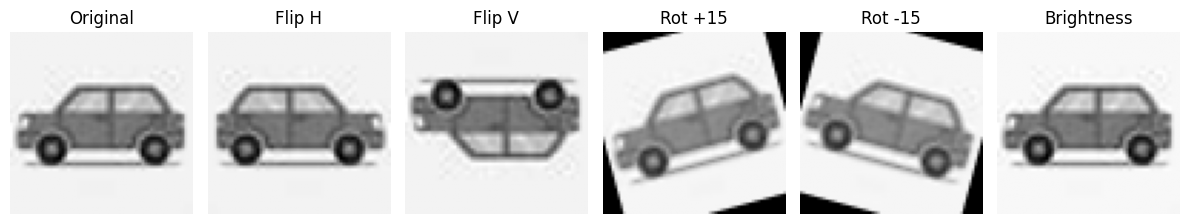

Motor total: 51
Contoh Augmentasi: Motor


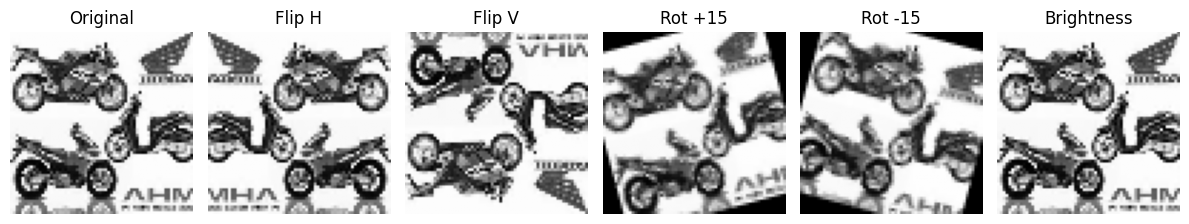


Total setelah augmentasi: 630
Total Data Latih: 504 | Total Data Uji: 126


In [ ]:
# LOAD, AUGMENTASI, DAN SPLIT DATA
def augmentasi_citra(citra):
    hasil_augmentasi = [citra]

    # Flip Horizontal & Vertikal
    hasil_augmentasi.append(cv2.flip(citra, 1)) # Flip H
    hasil_augmentasi.append(cv2.flip(citra, 0)) # Flip V

    # Rotasi
    pusat = (UKURAN_GAMBAR // 2, UKURAN_GAMBAR // 2)
    hasil_augmentasi.append(cv2.warpAffine(citra, cv2.getRotationMatrix2D(pusat, 15, 1.0), (UKURAN_GAMBAR, UKURAN_GAMBAR)))
    hasil_augmentasi.append(cv2.warpAffine(citra, cv2.getRotationMatrix2D(pusat, -15, 1.0), (UKURAN_GAMBAR, UKURAN_GAMBAR)))

    # Kecerahan (Brightness)
    kecerahan = np.clip(citra + np.random.uniform(-0.1, 0.1), 0, 1)
    hasil_augmentasi.append(kecerahan)

    return hasil_augmentasi

def tampilkan_contoh_augmentasi(citra, nama_kategori):
    aug = augmentasi_citra(citra)
    judul = ["Original", "Flip H", "Flip V", "Rot +15", "Rot -15", "Brightness"]

    print(f"Contoh Augmentasi: {nama_kategori}")
    plt.figure(figsize=(12, 4))
    for i in range(len(aug)):
        plt.subplot(1, 6, i+1)
        plt.imshow(aug[i], cmap="gray")
        plt.title(judul[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def siapkan_dataset(direktori_utama):
    X_kumpulan, y_kumpulan = [], []
    kategori = ["Mobil", "Motor"]

    for nilai_label, nama_kategori in enumerate(kategori):
        jalur_folder = os.path.join(direktori_utama, nama_kategori)
        daftar_file = glob(jalur_folder + "/*.jpg")

        print(f"{nama_kategori} total:", len(daftar_file))
        sudah_tampil = False

        for file in daftar_file:
            citra = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
            if citra is None or citra.shape[0] < 10:
                continue

            citra_resized = cv2.resize(citra, (UKURAN_GAMBAR, UKURAN_GAMBAR))
            citra_normalisasi = citra_resized / 255.0

            if not sudah_tampil:
                tampilkan_contoh_augmentasi(citra_normalisasi, nama_kategori)
                sudah_tampil = True

            for citra_aug in augmentasi_citra(citra_normalisasi):
                X_kumpulan.append(citra_aug)
                y_kumpulan.append(nilai_label)

    X_kumpulan = np.array(X_kumpulan)
    y_kumpulan = np.array(y_kumpulan)

    print(f"\nTotal setelah augmentasi: {len(X_kumpulan)}")

    indeks_acak = np.random.permutation(len(X_kumpulan))
    X_kumpulan, y_kumpulan = X_kumpulan[indeks_acak], y_kumpulan[indeks_acak]

    batas_split = int(len(X_kumpulan) * 0.8)
    return (X_kumpulan[:batas_split], X_kumpulan[batas_split:],
            y_kumpulan[:batas_split], y_kumpulan[batas_split:])

X_latih, X_uji, y_latih, y_uji = siapkan_dataset("data_kendaraan")
print(f"Total Data Latih: {len(X_latih)} | Total Data Uji: {len(X_uji)}")

In [ ]:
# KOMPONEN ARSITEKTUR CNN
class LapisanKonvolusi:
    def __init__(self, jumlah_filter, ukuran_kernel):
        self.ukuran_kernel = ukuran_kernel
        self.filter = np.random.randn(jumlah_filter, ukuran_kernel, ukuran_kernel) * 0.1

    def maju(self, input_citra):
        if len(input_citra.shape) == 2:
            input_citra = input_citra[np.newaxis, :, :]

        kanal, tinggi, lebar = input_citra.shape
        output = np.zeros((len(self.filter), tinggi - self.ukuran_kernel + 1, lebar - self.ukuran_kernel + 1))

        for f in range(len(self.filter)):
            for i in range(tinggi - self.ukuran_kernel + 1):
                for j in range(lebar - self.ukuran_kernel + 1):
                    area_receptive = input_citra[0, i:i+self.ukuran_kernel, j:j+self.ukuran_kernel]
                    output[f, i, j] = np.sum(area_receptive * self.filter[f])
        return output

class AktivasiReLU:
    def maju(self, x):
        return np.maximum(0, x)

class AktivasiTanh:
    def maju(self, x):
        return np.tanh(x)

class LapisanMaxPooling:
    def maju(self, x):
        filter_count, tinggi, lebar = x.shape
        output = np.zeros((filter_count, tinggi // 2, lebar // 2))

        for f in range(filter_count):
            for i in range(tinggi // 2):
                for j in range(lebar // 2):
                    output[f, i, j] = np.max(x[f, i*2:i*2+2, j*2:j*2+2])
        return output

class LapisanFlatten:
    def maju(self, x):
        return x.flatten()

class LapisanDense:
    def __init__(self, input_nodes):
        self.bobot = np.random.randn(input_nodes, 1) * 0.1
        self.bias = 0.0

    def maju(self, x):
        self.input_cache = x.reshape(-1, 1)
        output = np.dot(self.input_cache.T, self.bobot) + self.bias
        return output[0][0]

    def mundur(self, gradien_error):
        # Update bobot dan bias (Gradient Descent)
        self.bobot -= LEARNING_RATE * (self.input_cache * gradien_error)
        self.bias -= LEARNING_RATE * gradien_error

In [ ]:
# MODEL UTAMA & FUNGSI EVALUASI
class ModelCNN:
    def __init__(self, jumlah_lapisan_conv, tipe_aktivasi):
        # Inisialisasi arsitektur berdasarkan ablasi
        self.lapisan_conv = [LapisanKonvolusi(4 * (i + 1), 3) for i in range(jumlah_lapisan_conv)]

        self.tipe_aktivasi = tipe_aktivasi
        if tipe_aktivasi == 'relu':
            self.aktivasi = AktivasiReLU()
        elif tipe_aktivasi == 'tanh':
            self.aktivasi = AktivasiTanh()

        self.pooling = LapisanMaxPooling()
        self.flatten = LapisanFlatten()
        self.dense = None

    def prediksi_maju(self, x):
        for conv in self.lapisan_conv:
            x = conv.maju(x)
            x = self.aktivasi.maju(x)
            x = self.pooling.maju(x)

        x = self.flatten.maju(x)

        if self.dense is None:
            self.dense = LapisanDense(len(x))

        nilai_mentah = self.dense.maju(x)
        # Sigmoid di tahap akhir untuk klasifikasi biner
        self.probabilitas_output = 1 / (1 + np.exp(-np.clip(nilai_mentah, -500, 500)))
        return self.probabilitas_output

    def propagasi_mundur(self, target_aktual):
        # Perhitungan gradien error sederhana
        gradien = self.probabilitas_output - target_aktual
        self.dense.mundur(gradien)

def hitung_confusion_matrix(y_asli, y_prediksi):
    tp = sum((a == 1 and p == 1) for a, p in zip(y_asli, y_prediksi))
    tn = sum((a == 0 and p == 0) for a, p in zip(y_asli, y_prediksi))
    fp = sum((a == 0 and p == 1) for a, p in zip(y_asli, y_prediksi))
    fn = sum((a == 1 and p == 0) for a, p in zip(y_asli, y_prediksi))
    return tp, tn, fp, fn

def evaluasi_model(model, X, y):
    prediksi_label = []
    for fitur in X:
        prob = model.prediksi_maju(fitur)
        prediksi_label.append(1 if prob > 0.5 else 0)

    tp, tn, fp, fn = hitung_confusion_matrix(y, prediksi_label)
    akurasi = (tp + tn) / len(y) if len(y) > 0 else 0
    return akurasi, (tp, tn, fp, fn)

In [ ]:
# STUDI ABLASI (TRAINING LOOP)
def jalankan_ablasi(X_latih, y_latih, X_uji, y_uji, epoch=10):
    kombinasi_pengujian = [
        (1, 'relu'), (2, 'relu'), (3, 'relu'),
        (1, 'tanh'), (2, 'tanh'), (3, 'tanh')
    ]

    catatan_hasil = []

    for jml_conv, aktivasi in kombinasi_pengujian:
        print("\n====================")
        print(f"{jml_conv} Conv + {aktivasi}")
        print("====================")

        model = ModelCNN(jml_conv, aktivasi)
        waktu_mulai = time.time()

        # Training Loop
        for e in range(epoch):
            total_loss = 0
            for i in range(len(X_latih)):
                pred = model.prediksi_maju(X_latih[i])
                pred = np.clip(pred, 1e-7, 1-1e-7)
                loss = -(y_latih[i] * np.log(pred) + (1 - y_latih[i]) * np.log(1 - pred))
                total_loss += loss
                model.propagasi_mundur(y_latih[i])

            print(f"Epoch {e+1} Loss: {total_loss/len(X_latih):.4f}")

        waktu_selesai = time.time()
        durasi = waktu_selesai - waktu_mulai

        akurasi_uji, conf_matrix = evaluasi_model(model, X_uji, y_uji)
        print(f"Accuracy: {akurasi_uji}")

        catatan_hasil.append({
            "model": f"{jml_conv}-{aktivasi}",
            "acc": akurasi_uji,
            "time": durasi,
            "Conf_Matrix (TP,TN,FP,FN)": conf_matrix
        })

    return pd.DataFrame(catatan_hasil)

df_hasil_ablasi = jalankan_ablasi(X_latih, y_latih, X_uji, y_uji, epoch=10)


1 Conv + relu
Epoch 1 Loss: 0.7070
Epoch 2 Loss: 0.6783
Epoch 3 Loss: 0.6557
Epoch 4 Loss: 0.6367
Epoch 5 Loss: 0.6201
Epoch 6 Loss: 0.6051
Epoch 7 Loss: 0.5915
Epoch 8 Loss: 0.5789
Epoch 9 Loss: 0.5672
Epoch 10 Loss: 0.5561
Accuracy: 0.6666666666666666

2 Conv + relu
Epoch 1 Loss: 0.6930
Epoch 2 Loss: 0.6924
Epoch 3 Loss: 0.6920
Epoch 4 Loss: 0.6916
Epoch 5 Loss: 0.6913
Epoch 6 Loss: 0.6909
Epoch 7 Loss: 0.6906
Epoch 8 Loss: 0.6902
Epoch 9 Loss: 0.6899
Epoch 10 Loss: 0.6895
Accuracy: 0.5317460317460317

3 Conv + relu
Epoch 1 Loss: 0.6937
Epoch 2 Loss: 0.6935
Epoch 3 Loss: 0.6934
Epoch 4 Loss: 0.6934
Epoch 5 Loss: 0.6934
Epoch 6 Loss: 0.6934
Epoch 7 Loss: 0.6934
Epoch 8 Loss: 0.6934
Epoch 9 Loss: 0.6934
Epoch 10 Loss: 0.6933
Accuracy: 0.5079365079365079

1 Conv + tanh
Epoch 1 Loss: 0.7528
Epoch 2 Loss: 0.6563
Epoch 3 Loss: 0.6096
Epoch 4 Loss: 0.5763
Epoch 5 Loss: 0.5504
Epoch 6 Loss: 0.5291
Epoch 7 Loss: 0.5107
Epoch 8 Loss: 0.4945
Epoch 9 Loss: 0.4800
Epoch 10 Loss: 0.4669
Accuracy:


========== TABEL HASIL ABLASI & PERBANDINGAN ==========
 model      acc        time  TP (True Pos)  TN (True Neg)  FP (False Pos)  FN (False Neg)
1-relu 0.666667  795.898023             31             53              11              31
2-relu 0.531746 1110.805233              3             64               0              59
3-relu 0.507937 1196.295670              0             64               0              62
1-tanh 0.738095  778.210301             40             53              11              22
2-tanh 0.666667 1112.103251             28             56               8              34
3-tanh 0.523810 1203.738896              2             64               0              60


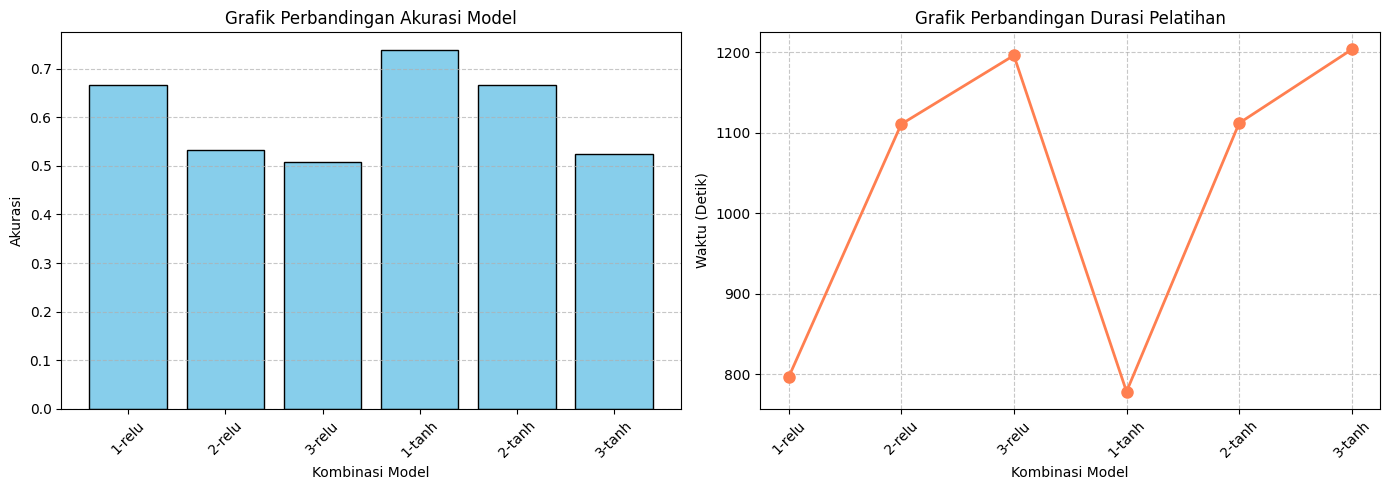

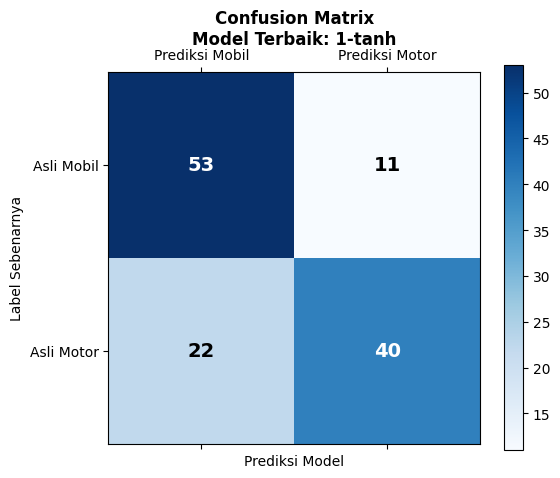


========== ANALISIS & KESIMPULAN CEPAT ==========
1. Model Terbaik (Akurasi Maksimal) : 1-tanh (Akurasi: 0.7381)
2. Model Tercepat (Waktu Minimal)   : 1-tanh (Waktu: 778.21 detik)

Trade-off Akurasi vs Waktu:
- Model 1-tanh sangat efisien karena tidak hanya memiliki akurasi tertinggi, tetapi juga memakan waktu komputasi paling sedikit.


In [ ]:
# VISUALISASI, CONFUSION MATRIX, DAN ANALISIS PERFORMA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\n========== TABEL HASIL ABLASI & PERBANDINGAN ==========")
df_tabel = df_hasil_ablasi[['model', 'acc', 'time', 'Conf_Matrix (TP,TN,FP,FN)']].copy()

df_tabel[['TP (True Pos)', 'TN (True Neg)', 'FP (False Pos)', 'FN (False Neg)']] = pd.DataFrame(df_tabel['Conf_Matrix (TP,TN,FP,FN)'].tolist(), index=df_tabel.index)
df_tabel_tampil = df_tabel[['model', 'acc', 'time', 'TP (True Pos)', 'TN (True Neg)', 'FP (False Pos)', 'FN (False Neg)']]

pd.set_option('display.max_columns', None)
print(df_tabel_tampil.to_string(index=False))

# GRAFIK PERBANDINGAN (AKURASI VS WAKTU)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Akurasi (Bar Chart)
ax1.bar(df_tabel_tampil["model"], df_tabel_tampil["acc"], color='skyblue', edgecolor='black')
ax1.set_title("Grafik Perbandingan Akurasi Model")
ax1.set_ylabel("Akurasi")
ax1.set_xlabel("Kombinasi Model")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik 2: Waktu (Line Chart)
ax2.plot(df_tabel_tampil["model"], df_tabel_tampil["time"], marker='o', color='coral', linewidth=2, markersize=8)
ax2.set_title("Grafik Perbandingan Durasi Pelatihan")
ax2.set_ylabel("Waktu (Detik)")
ax2.set_xlabel("Kombinasi Model")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# VISUALISASI CONFUSION MATRIX (UNTUK MODEL TERBAIK)
# Mencari model dengan akurasi tertinggi
idx_terbaik = df_tabel_tampil['acc'].idxmax()
model_terbaik = df_tabel_tampil.loc[idx_terbaik]

tp = model_terbaik['TP (True Pos)']
tn = model_terbaik['TN (True Neg)']
fp = model_terbaik['FP (False Pos)']
fn = model_terbaik['FN (False Neg)']

# Menyusun matriks: [TN, FP] di baris pertama (Kelas 0), [FN, TP] di baris kedua (Kelas 1)
matriks_cm = np.array([[tn, fp],
                       [fn, tp]])

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(matriks_cm, cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix\nModel Terbaik: {model_terbaik['model']}", pad=20, fontweight='bold')
fig.colorbar(cax)

# Menambahkan angka di dalam kotak matriks
batas_warna = (tp + tn + fp + fn) / 4
for i in range(2):
    for j in range(2):
        nilai = matriks_cm[i, j]
        warna_teks = 'white' if nilai > batas_warna else 'black'
        ax.text(j, i, str(nilai), va='center', ha='center', size=14, color=warna_teks, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Prediksi Mobil', 'Prediksi Motor'])
ax.set_yticklabels(['Asli Mobil', 'Asli Motor'])
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

# KESIMPULAN
print("\n========== ANALISIS & KESIMPULAN CEPAT ==========")
model_tercepat = df_tabel_tampil.loc[df_tabel_tampil['time'].idxmin()]

print(f"1. Model Terbaik (Akurasi Maksimal) : {model_terbaik['model']} (Akurasi: {model_terbaik['acc']:.4f})")
print(f"2. Model Tercepat (Waktu Minimal)   : {model_tercepat['model']} (Waktu: {model_tercepat['time']:.2f} detik)")

print("\nTrade-off Akurasi vs Waktu:")
if model_terbaik['model'] == model_tercepat['model']:
    print(f"- Model {model_terbaik['model']} sangat efisien karena tidak hanya memiliki akurasi tertinggi, tetapi juga memakan waktu komputasi paling sedikit.")
else:
    print(f"- Jika tujuan utama adalah performa akurasi klasifikasi, maka arsitektur '{model_terbaik['model']}' adalah pilihan utama.")
    print(f"- Namun, jika implementasi membutuhkan kecepatan proses (misalnya komputasi terbatas), '{model_tercepat['model']}' menawarkan waktu training yang lebih singkat dengan konsekuensi sedikit penurunan akurasi.")